# 04 — Clustering

Logic lives in `src/clustering.py`; this runs it and checks the output. Feature selection and model choice are both evidence-based, not asserted - see `clustering.py`'s module docstring for the full reasoning, summarized below.

In [30]:
import sys, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")#, message="n_jobs value 1 overridden")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, HDBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

from features import build_ppg_features
from anomaly_checking import flag_anomalies
from clustering import (
    FEATURE_COLS, prep_matrix, reduce_umap, choose_k, fit, fit_umap, fit_umap_hdbscan,
    profile, stability_ari, stability_ari_umap, stability_ari_umap_hdbscan,
    flag_weak_fits, flag_weak_fits_umap,
)
from visuals import plot_growth_vs_erosion, plot_promo_efficiency, plot_categorical_mix

raw = pd.read_csv("../data/raw/ECON_POS_anonymized.csv", low_memory=False)
feats_all = build_ppg_features(raw)

anoms = flag_anomalies(feats_all).reindex(feats_all.index)
feats = feats_all.loc[~anoms.is_anomaly]
print(f"{len(feats)} products, {len(FEATURE_COLS)} clustering features ({int(anoms.is_anomaly.sum())} anomalies removed)")

X, scaler = prep_matrix(feats)
print("prep_matrix:", X.shape, " any NaN:", bool(pd.isna(X).any()))

347 products, 22 clustering features (19 anomalies removed)
prep_matrix: (347, 22)  any NaN: False


## Feature selection

22 behavioural features survive into `FEATURE_COLS`, out of ~30 candidates — dropped anything correlated above 0.85 with something already in the set (full table in clustering.py's docstring)

## Model choice: KMeans vs. GMM vs. HDBSCAN

Fit all three on the identical matrix

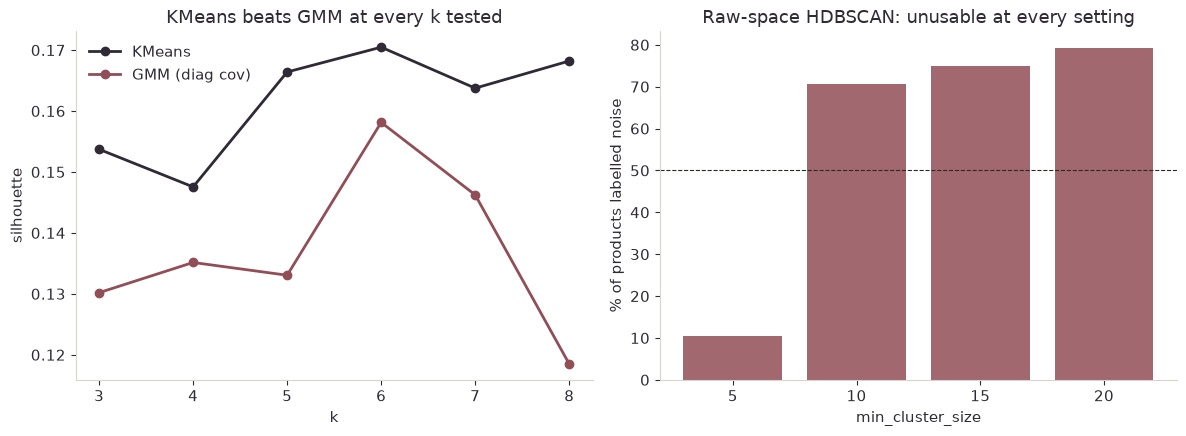

In [31]:
k_range = range(3, 9)
rows = []
for k in k_range:
    km_sil = silhouette_score(X, KMeans(n_clusters=k, n_init=10, random_state=42).fit(X).labels_)
    gmm = GaussianMixture(n_components=k, covariance_type="diag", random_state=42, n_init=5).fit(X)
    gmm_sil = silhouette_score(X, gmm.predict(X))
    rows.append({"k": k, "kmeans_sil": km_sil, "gmm_sil": gmm_sil})
model_cmp = pd.DataFrame(rows)

hdbscan_noise = {mcs: (HDBSCAN(min_cluster_size=mcs).fit(X).labels_ == -1).mean() for mcs in [5, 10, 15, 20]}

gmm6 = GaussianMixture(n_components=6, covariance_type="diag", random_state=42, n_init=5).fit(X)
gmm_median_prob = np.median(gmm6.predict_proba(X).max(axis=1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(model_cmp.k, model_cmp.kmeans_sil, "o-", color="#2F2A35", label="KMeans", linewidth=2)
axes[0].plot(model_cmp.k, model_cmp.gmm_sil, "o-", color="#914E56", label="GMM (diag cov)", linewidth=2)
axes[0].set_xlabel("k"); axes[0].set_ylabel("silhouette")
axes[0].legend(frameon=False); axes[0].set_title("KMeans beats GMM at every k tested")

mcs_labels = [str(m) for m in hdbscan_noise]
axes[1].bar(mcs_labels, [v * 100 for v in hdbscan_noise.values()], color="#914E56", alpha=0.85)
axes[1].axhline(50, color="#2C2923", linestyle="--", linewidth=0.8)
axes[1].set_xlabel("min_cluster_size"); axes[1].set_ylabel("% of products labelled noise")
axes[1].set_title("Raw-space HDBSCAN: unusable at every setting")
plt.tight_layout(); plt.show()

KMeans beats GMM at every k tested (silhouette 0.13–0.17 vs. 0.13–0.14) — not by default. GMM's soft-membership advantage doesn't materialize either: median max-membership-probability is 1.0, no real ambiguity for it to capture.
Raw-space HDBSCAN is unusable, 61–100% of products labelled noise depending on min_cluster_size, curse-of-dimensionality problem (22 features, 347 points)

## A more exciting option, tested: UMAP + KMeans

22 dimensions is pushing the high end for Euclidean distance at 347 points — UMAP's non-linear reduction can reveal structure raw distance misses, worth testing. UMAP can also manufacture apparent separation as an embedding artifact, so this gets the same bootstrap-stability check as everything else.
Slow part of the notebook (a few minutes): each UMAP-space bootstrap re-embeds from scratch rather than reusing a fitted reducer. Fine for a one-off validation; would need caching if this ran routinely

In [32]:
X_umap = reduce_umap(X, seed=42)

N_BOOT = 30
rows = []
for k in range(3, 9):
    raw_sil = silhouette_score(X, KMeans(n_clusters=k, n_init=10, random_state=42).fit(X).labels_)
    raw_ari = stability_ari(feats, k=k, n_boot=N_BOOT)
    umap_km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_umap)
    umap_sil = silhouette_score(X_umap, umap_km.labels_)
    umap_ari = stability_ari_umap(feats, k=k, n_boot=N_BOOT)
    rows.append({"k": k, "raw_sil": raw_sil, "raw_ari": raw_ari, "umap_sil": umap_sil, "umap_ari": umap_ari})
k_sweep = pd.DataFrame(rows)
k_sweep

,k,raw_sil,raw_ari,umap_sil,umap_ari
0,3,0.153721,0.860621,0.484050,0.545611
1,4,0.147547,0.894069,0.492727,0.662752
2,5,0.166405,0.835546,0.561219,0.761973
3,6,0.170476,0.727443,0.546898,0.767814
4,7,0.163751,0.646584,0.592805,0.855655
5,8,0.168210,0.789865,0.561948,0.822031


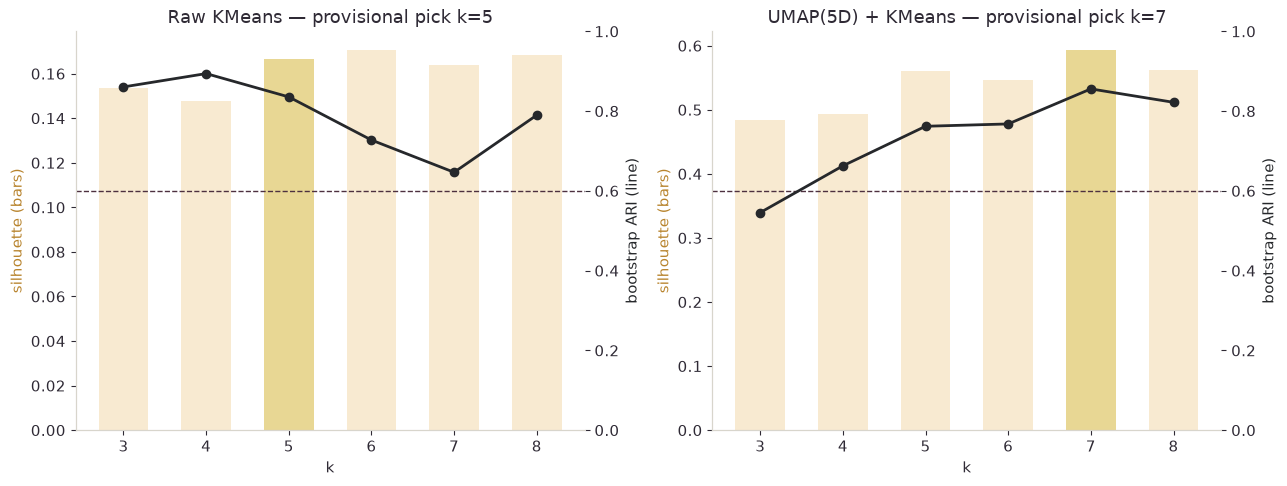

In [33]:
STABILITY_THRESHOLD = 0.6
CANDIDATE_RAW_K = 5   # provisional - confirmed/tested below
CANDIDATE_UMAP_K = 7  # provisional - confirmed/tested below

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, sil_col, ari_col, title, chosen_k in [
    (axes[0], "raw_sil", "raw_ari", "Raw KMeans", CANDIDATE_RAW_K),
    (axes[1], "umap_sil", "umap_ari", "UMAP(5D) + KMeans", CANDIDATE_UMAP_K),
]:
    colors = ["#E6D389" if k == chosen_k else "#F8E8CC" for k in k_sweep.k]
    ax2 = ax.twinx()
    ax.bar(k_sweep.k, k_sweep[sil_col], color=colors, alpha=0.9, width=0.6, zorder=2)
    ax2.plot(k_sweep.k, k_sweep[ari_col], "o-", color="#26282B", zorder=3, linewidth=2)
    ax2.axhline(STABILITY_THRESHOLD, color="#4D303F", linestyle="--", linewidth=1)
    ax.set_xlabel("k"); ax.set_ylabel("silhouette (bars)", color="#B8842E")
    ax2.set_ylabel("bootstrap ARI (line)", color="#26282B"); ax2.set_ylim(0, 1)
    ax.set_title(f"{title} — provisional pick k={chosen_k}")
plt.tight_layout(); plt.show()

Silhouette alone would potentially pick badly here — it peaks at k=6 (raw) and k=7 (UMAP)
k=4 vs. 5 (raw) are close enoug on both axes

In [34]:
print("raw KMeans -- 5 independent bootstrap seeds, n_boot=20 each:")
for k in [4, 5, 6]:
    vals = [stability_ari(feats, k=k, n_boot=20, seed=s) for s in [11, 22, 33, 44, 55]]
    print(f"  k={k}: {[round(v, 3) for v in vals]}  mean={np.mean(vals):.3f}")

print("\nUMAP+KMeans -- 3 independent bootstrap seeds, n_boot=15 each:")
for k in [6, 7]:
    vals = [stability_ari_umap(feats, k=k, n_boot=15, seed=s) for s in [11, 22, 33]]
    print(f"  k={k}: {[round(v, 3) for v in vals]}  mean={np.mean(vals):.3f}")

raw KMeans -- 5 independent bootstrap seeds, n_boot=20 each:
  k=4: [0.858, 0.879, 0.904, 0.831, 0.86]  mean=0.866
  k=5: [0.83, 0.825, 0.838, 0.815, 0.81]  mean=0.824
  k=6: [0.73, 0.727, 0.741, 0.715, 0.723]  mean=0.727

UMAP+KMeans -- 3 independent bootstrap seeds, n_boot=15 each:
  k=6: [0.764, 0.741, 0.813]  mean=0.773
  k=7: [0.844, 0.833, 0.868]  mean=0.848


**UMAP: k=7 comes out ahead consistently** across every seed tested

In [35]:
labels4, _, _ = fit(feats, k=4, seed=42)
labels5, _, _ = fit(feats, k=5, seed=42)
print("k=4 vs k=5 crosstab (does k=5 split one k=4 cluster cleanly, or reshuffle everything?):")
print(pd.crosstab(labels4, labels5))

prof5_check = profile(feats, labels5)
print(prof5_check[["avg_weekly_sales", "promo_lift", "promo_week_share", "substitute_correlation", "peer_correlation", "n_ppgs"]])

k=4 vs k=5 crosstab (does k=5 split one k=4 cluster cleanly, or reshuffle everything?):
cluster   0   1   2   3   4
cluster                    
0         1   0   0   0  98
1         0  38  64   0   2
2         0   4   1  58   0
3        67  12   1   0   1
         avg_weekly_sales  promo_lift  promo_week_share  \
cluster                                                   
0                5686.108      55.540             0.276   
1               14875.398       1.231             0.572   
2                5933.435       2.116             0.684   
3               37606.811       5.744             0.951   
4                 873.682       3.307             0.162   

         substitute_correlation  peer_correlation  n_ppgs  
cluster                                                    
0                         0.099             0.279      68  
1                         0.339             0.696      54  
2                         0.091             0.248      66  
3                         0.06

## Potentially primary model?: KMeans, k=5

In [36]:
labels, km, scaler = fit(feats, k=5)
prof = profile(feats, labels)
prof

,avg_weekly_sales,momentum,mat_growth,promo_lift,promo_intensity_effect,growth_rate,acv_trend,price_elasticity,promo_effect_ctrl,avg_acv,...,n_retailers,avg_price,is_new,is_delisted,peer_correlation,promo_visibility_share,promo_lift_retailer_cv,acv_retailer_cv,substitute_correlation,n_ppgs
cluster,,,,,,,,,,,,,,,,,,,,,
0,5686.108,0.693,0.086,55.540,1.040,-0.068,-0.224,0.240,0.202,6.222,...,3.0,1.156,0.0,0.0,0.279,0.347,0.931,0.950,0.099,68
1,14875.398,0.980,0.894,1.231,0.589,-0.002,-0.070,0.350,0.084,48.516,...,1.0,2.396,0.0,0.0,0.696,0.319,0.000,0.000,0.339,54
2,5933.435,1.040,1.049,2.116,0.724,0.012,0.006,0.236,0.043,1.654,...,1.0,2.852,0.0,0.0,0.248,0.000,0.000,0.000,0.091,66
3,37606.811,1.000,0.912,5.744,1.716,0.004,-0.047,0.496,0.493,37.406,...,5.0,4.337,0.0,0.0,-0.004,0.439,0.720,0.687,0.064,58
4,873.682,0.708,0.335,3.307,0.257,-0.041,-0.007,0.071,0.024,0.553,...,1.0,0.656,0.0,0.0,0.248,0.000,0.000,0.000,0.091,101


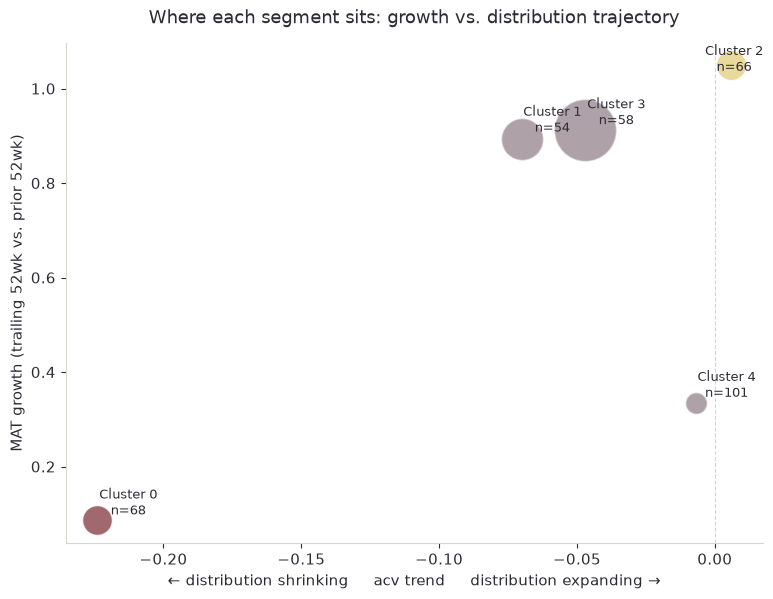

In [37]:
fig, ax = plt.subplots(figsize=(9, 6.5))
plot_growth_vs_erosion(prof, ax=ax)
plt.show()

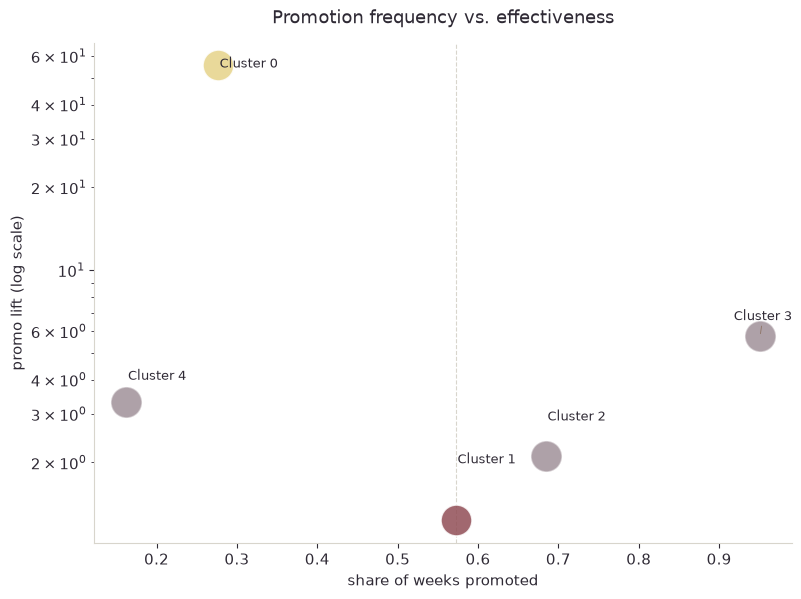

In [38]:
fig, ax = plt.subplots(figsize=(9, 6.5))
plot_promo_efficiency(prof, ax=ax)
plt.show()

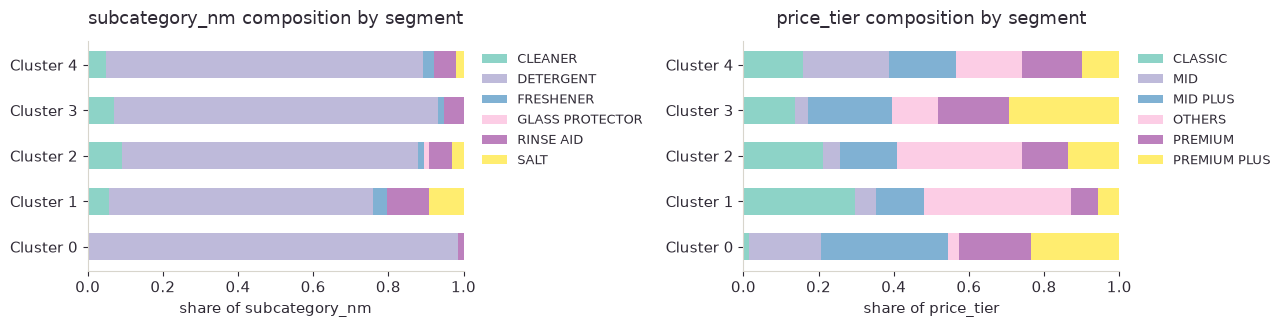

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.4))
plot_categorical_mix(feats, labels, "subcategory_nm", ax=axes[0])
plot_categorical_mix(feats, labels, "price_tier", ax=axes[1])
plt.tight_layout(); plt.show()

Neither chart is a solid-colour bar per cluster

## Stability and weak fits

bootstrap ARI: 0.836   weak fits: 25/347


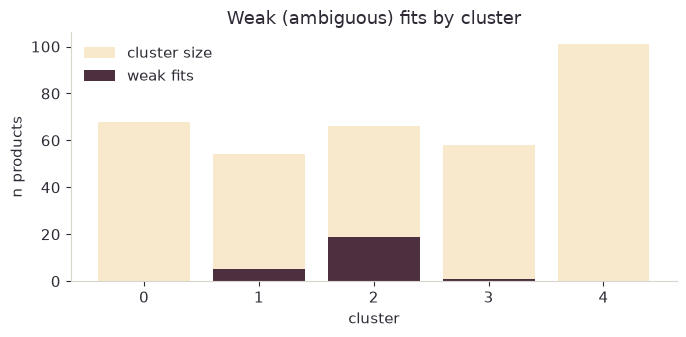

In [40]:
ari = stability_ari(feats, k=5, n_boot=30)
weak = flag_weak_fits(feats, labels)
print(f"bootstrap ARI: {ari:.3f}   weak fits: {weak.sum()}/{len(weak)}")

weak_by_cluster = pd.DataFrame({
    "cluster_size": labels.value_counts().sort_index(),
    "weak_fits": weak.groupby(labels).sum(),
})
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(weak_by_cluster.index.astype(str), weak_by_cluster.cluster_size, color="#F8E8CC", label="cluster size")
ax.bar(weak_by_cluster.index.astype(str), weak_by_cluster.weak_fits, color="#4D303F", label="weak fits")
ax.set_xlabel("cluster"); ax.set_ylabel("n products"); ax.legend(frameon=False)
ax.set_title("Weak (ambiguous) fits by cluster")
plt.tight_layout(); plt.show()

## Validated exciting alternative: UMAP(5D) + KMeans, k=7

Real improvement on both silhouette and stability, but not primary? A KMeans centroid is a business fact; a UMAP centroid lives in an abstract 5D space with extra hyperparameters to justify. Given the brief's interpretability requirement, the simpler method stays primary, this is a validated alternative

In [41]:
labels_umap, km_umap, _ = fit_umap(feats, k=7, seed=42)
prof_umap = profile(feats, labels_umap)
prof_umap

,avg_weekly_sales,momentum,mat_growth,promo_lift,promo_intensity_effect,growth_rate,acv_trend,price_elasticity,promo_effect_ctrl,avg_acv,...,n_retailers,avg_price,is_new,is_delisted,peer_correlation,promo_visibility_share,promo_lift_retailer_cv,acv_retailer_cv,substitute_correlation,n_ppgs
cluster,,,,,,,,,,,,,,,,,,,,,
0,54410.971,0.966,0.902,7.002,1.872,0.005,-0.011,0.572,0.628,38.348,...,5.0,4.858,0.0,0.0,-0.047,0.477,0.577,0.624,0.064,42
1,1893.913,0.908,0.511,2.755,0.487,-0.010,-0.002,0.141,0.020,0.799,...,1.0,1.105,0.0,0.0,0.248,0.000,0.000,0.000,0.074,92
2,5537.250,0.972,0.972,2.016,0.623,0.043,0.054,0.239,0.038,12.181,...,1.0,2.877,1.0,0.0,0.248,0.185,0.000,0.000,0.091,26
3,9821.764,0.633,0.169,5.148,1.132,-0.047,-0.401,0.210,0.228,23.448,...,2.0,2.170,0.0,0.0,0.431,0.332,0.637,0.797,0.130,76
4,18979.444,1.026,1.036,1.064,0.527,0.002,0.020,0.962,0.044,63.240,...,2.0,2.354,0.0,0.0,0.716,0.305,0.043,0.053,0.276,31
5,1294.817,0.500,0.223,4.561,0.509,-0.068,-0.019,0.070,0.040,0.718,...,1.0,0.786,0.0,1.0,0.248,0.000,0.000,0.000,0.117,40
6,4918.597,0.841,0.108,93.413,0.895,-0.066,-0.194,0.249,0.133,5.421,...,3.0,0.815,0.0,0.0,0.198,0.321,0.868,1.107,0.043,40


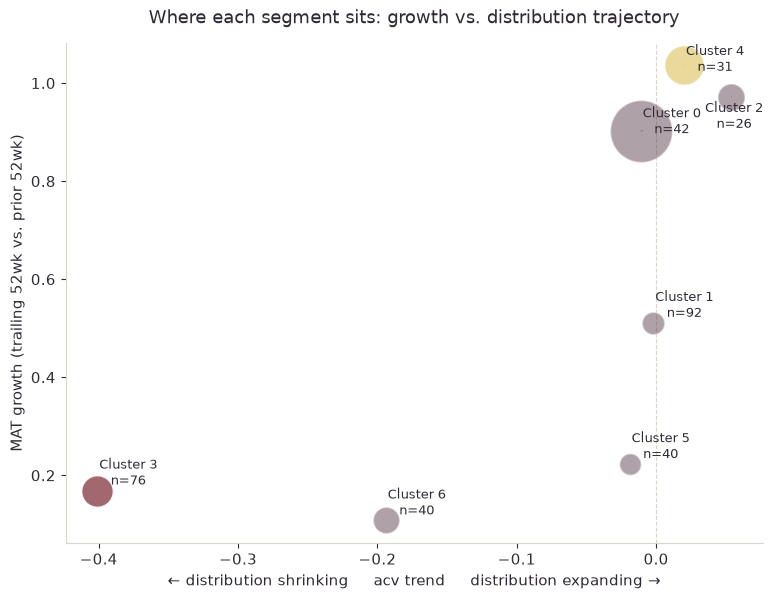

In [42]:
fig, ax = plt.subplots(figsize=(9, 6.5))
plot_growth_vs_erosion(prof_umap, ax=ax)
plt.show()

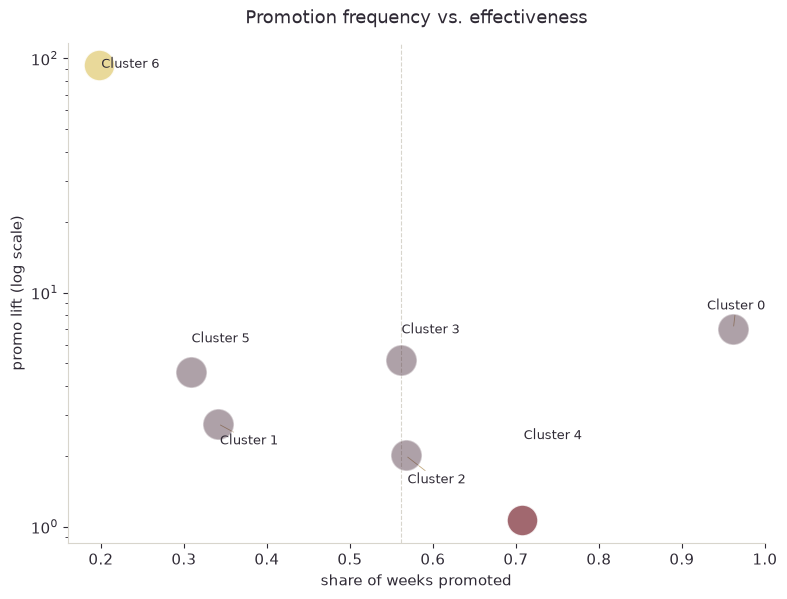

In [43]:
fig, ax = plt.subplots(figsize=(9, 6.5))
plot_promo_efficiency(prof_umap, ax=ax)
plt.show()

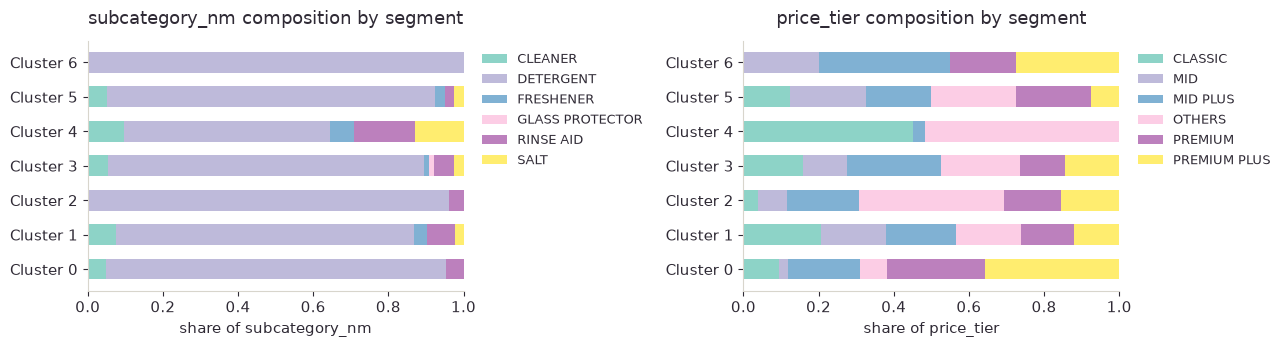

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
plot_categorical_mix(feats, labels_umap, "subcategory_nm", ax=axes[0])
plot_categorical_mix(feats, labels_umap, "price_tier", ax=axes[1])
plt.tight_layout(); plt.show()

In [45]:
weak_umap = flag_weak_fits_umap(feats, labels_umap)
ari_umap = stability_ari_umap(feats, k=7, n_boot=30)
print(f"bootstrap ARI: {ari_umap:.3f}   weak fits (UMAP space): {weak_umap.sum()}/{len(weak_umap)}")

bootstrap ARI: 0.856   weak fits (UMAP space): 5/347


## UMAP + HDBSCAN

Raw-space HDBSCAN was unusable earlier. HDBSCAN is specifically designed to work on embeddings like UMAP's output, so worth testing properly rather than assuming the earlier rejection still holds. Kept brief — this isn't the recommendation either way, so it doesn't need the same depth of treatment as the two models above.

In [46]:
rows = []
for mcs in [5, 8, 15, 22]:
    labels_h, model_h, _ = fit_umap_hdbscan(feats, min_cluster_size=mcs, seed=42)
    n_noise = int((labels_h == -1).sum())
    n_clusters = labels_h[labels_h != -1].nunique()
    ari_h = stability_ari_umap_hdbscan(feats, min_cluster_size=mcs, n_boot=10)
    rows.append({"min_cluster_size": mcs, "n_clusters": n_clusters, "noise_pct": n_noise / len(labels_h) * 100, "bootstrap_ari": ari_h})
hdbscan_sweep = pd.DataFrame(rows)
hdbscan_sweep

,min_cluster_size,n_clusters,noise_pct,bootstrap_ari
0,5,11,6.051873,0.671062
1,8,10,10.951009,0.704691
2,15,6,5.763689,0.699588
3,22,4,0.000000,0.577838


Better-behaved than raw-space HDBSCAN, and the ranking flipped from before: min_cluster_size=22 (0% noise) is now the weakest on stability (ARI 0.578, below the 0.6 threshold), while 8 and 15 clear it comfortably (0.70, 0.70) with modest noise (11%, 6%). Still, nothing here beats the two recommended models (0.83 raw, 0.85 UMAP) — kept as a tested, documented option, not a recommendation.

## Save

In [47]:
import os
os.makedirs("../data/processed", exist_ok=True)
prof.to_csv("../data/processed/cluster_profile_kmeans.csv")
prof_umap.to_csv("../data/processed/cluster_profile_umap.csv")
pd.DataFrame({
    "kmeans_k5": labels,
    "umap_k7": labels_umap,
    "weak_fit": weak,
    "weak_fit_umap": weak_umap,
}).to_csv("../data/processed/ppg_cluster_labels.csv")

## Business interpretation
Cluster profiles

In [48]:
import seaborn as sns

def plot_cluster_heatmap(prof, title):
    prof_z = (prof[FEATURE_COLS] - prof[FEATURE_COLS].mean()) / prof[FEATURE_COLS].std(ddof=0)
    fig, ax = plt.subplots(figsize=(16, 0.6 * len(prof) + 2))
    sns.heatmap(prof_z, cmap="RdBu_r", center=0, annot=True, fmt=".1f",
                annot_kws={"size": 7}, cbar_kws={"label": "z-score vs. cross-cluster mean"}, ax=ax)
    ax.set_title(title, fontsize=13, pad=12)
    ax.set_xlabel(""); ax.set_ylabel("cluster")
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.tight_layout()
    plt.show()

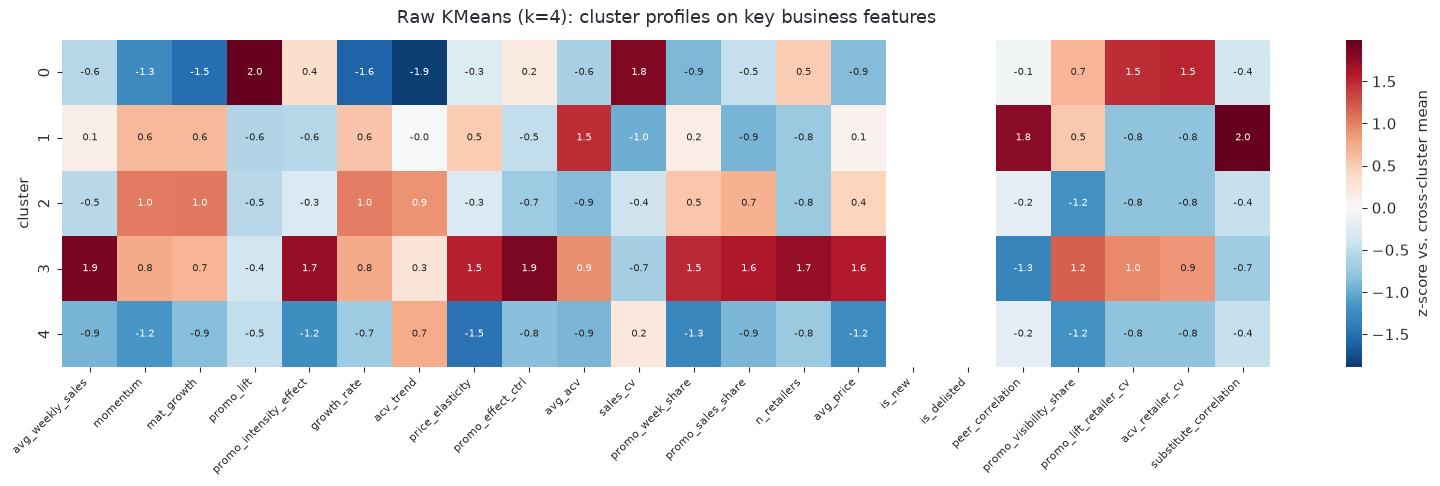

In [49]:
plot_cluster_heatmap(prof, "Raw KMeans (k=4): cluster profiles on key business features")

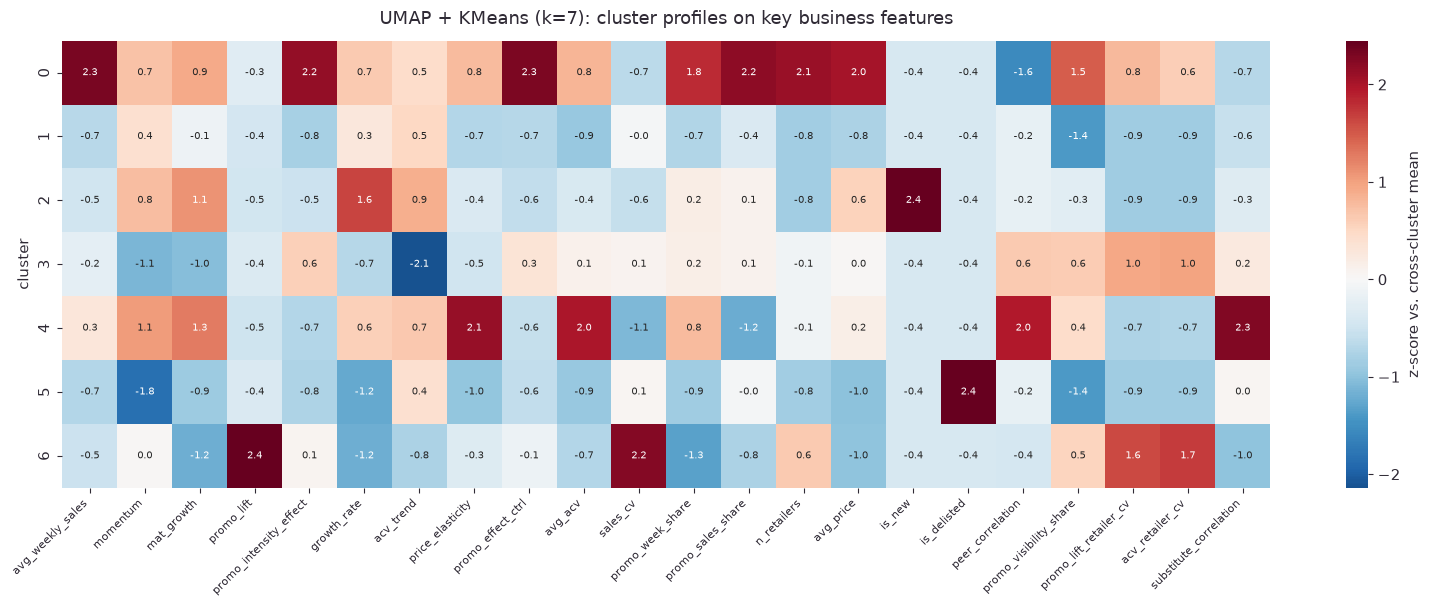

In [50]:
plot_cluster_heatmap(prof_umap, "UMAP + KMeans (k=7): cluster profiles on key business features")

## Representative products of each cluster

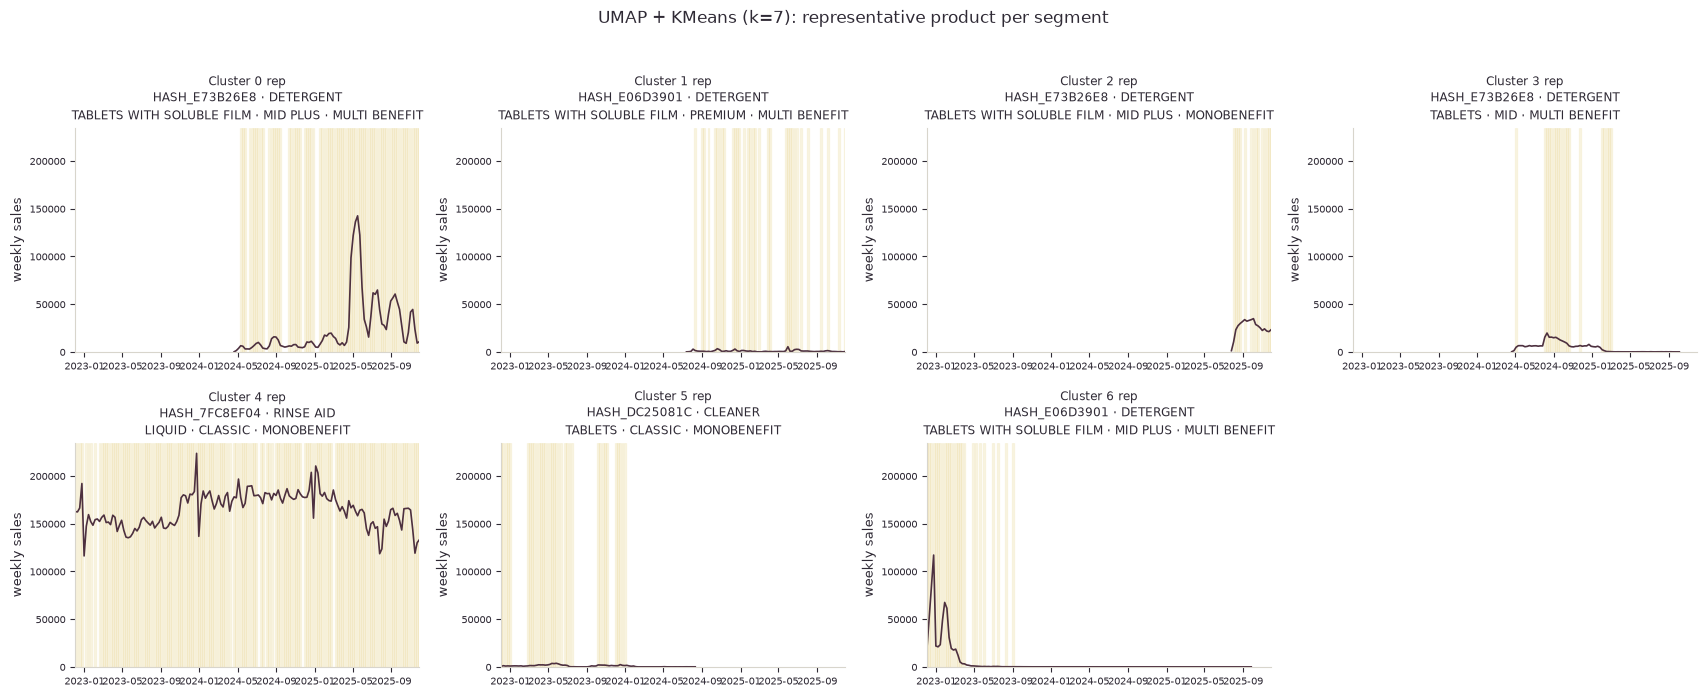

In [51]:
from clustering import representative_ppgs
from visuals import plot_ppg_trend_grid
from visuals import product_weekly_sales

weekly_sales = product_weekly_sales(raw)

reps_umap = representative_ppgs(feats, labels_umap, km_umap, X_umap)
rep_names_umap = {f"Cluster {cid} rep": ppg for cid, ppg in reps_umap.items()}

axes = plot_ppg_trend_grid(weekly_sales, rep_names_umap, feats, ncols=4)
plt.suptitle("UMAP + KMeans (k=7): representative product per segment", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

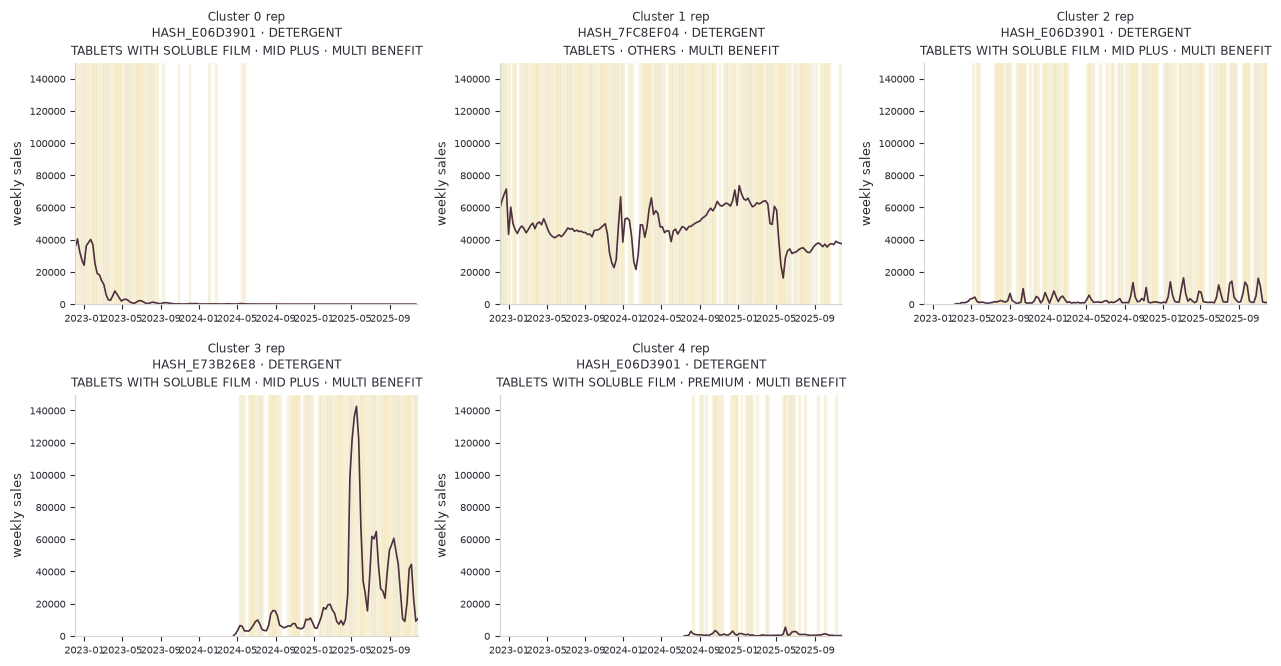

In [52]:
reps = representative_ppgs(feats, labels, km, X)
rep_names = {f"Cluster {cid} rep": ppg for cid, ppg in reps.items()}

axes = plot_ppg_trend_grid(weekly_sales, rep_names, feats, ncols=3)
ax.set_title("Raw KMeans (k=5): representative product per segment", fontsize=12)
plt.tight_layout(); plt.show()

At the end I would make the choice between models based on stakeholders' feedback. I like the UMAP clustering but I also want to acknowledge these clusters are more difficult to interpret.

In [53]:
reps_umap


{np.int32(0): 'PPG_ATTR1_DE0C4AF4 | PPG_ATTR2_2BEF0FAC | PPG_ATTR3_E73B26E8 | PPG_ATTR4_AE186179 | PPG_ATTR5_83F6910A | PPG_ATTR6_793F866E | PPG_ATTR7_A87D5006 | PPG_ATTR8_D1C41E8A | PPG_ATTR9_C4CA4238 | PPG_ATTR12_2BEF0FAC',
 np.int32(1): 'PPG_ATTR1_F6394E71 | PPG_ATTR2_2BEF0FAC | PPG_ATTR3_E06D3901 | PPG_ATTR4_AE186179 | PPG_ATTR5_6E46E132 | PPG_ATTR6_793F866E | PPG_ATTR7_164D04A0 | PPG_ATTR8_FAF10FA8 | PPG_ATTR9_C4CA4238 | PPG_ATTR12_2BEF0FAC',
 np.int32(2): 'PPG_ATTR1_DE0C4AF4 | PPG_ATTR2_2BEF0FAC | PPG_ATTR3_E73B26E8 | PPG_ATTR4_AE186179 | PPG_ATTR5_582ECBA5 | PPG_ATTR6_793F866E | PPG_ATTR7_A87D5006 | PPG_ATTR8_D8EF598E | PPG_ATTR9_C4CA4238 | PPG_ATTR12_2BEF0FAC',
 np.int32(3): 'PPG_ATTR1_DE0C4AF4 | PPG_ATTR2_2BEF0FAC | PPG_ATTR3_E73B26E8 | PPG_ATTR4_AE186179 | PPG_ATTR5_D71441D1 | PPG_ATTR6_92B72C5A | PPG_ATTR7_A87D5006 | PPG_ATTR8_04AA706D | PPG_ATTR9_C4CA4238 | PPG_ATTR12_2BEF0FAC',
 np.int32(4): 'PPG_ATTR1_7FC8EF04 | PPG_ATTR2_2BEF0FAC | PPG_ATTR3_7FC8EF04 | PPG_ATTR4_A20E9B75

In [54]:
display(prof_umap)

,avg_weekly_sales,momentum,mat_growth,promo_lift,promo_intensity_effect,growth_rate,acv_trend,price_elasticity,promo_effect_ctrl,avg_acv,...,n_retailers,avg_price,is_new,is_delisted,peer_correlation,promo_visibility_share,promo_lift_retailer_cv,acv_retailer_cv,substitute_correlation,n_ppgs
cluster,,,,,,,,,,,,,,,,,,,,,
0,54410.971,0.966,0.902,7.002,1.872,0.005,-0.011,0.572,0.628,38.348,...,5.0,4.858,0.0,0.0,-0.047,0.477,0.577,0.624,0.064,42
1,1893.913,0.908,0.511,2.755,0.487,-0.010,-0.002,0.141,0.020,0.799,...,1.0,1.105,0.0,0.0,0.248,0.000,0.000,0.000,0.074,92
2,5537.250,0.972,0.972,2.016,0.623,0.043,0.054,0.239,0.038,12.181,...,1.0,2.877,1.0,0.0,0.248,0.185,0.000,0.000,0.091,26
3,9821.764,0.633,0.169,5.148,1.132,-0.047,-0.401,0.210,0.228,23.448,...,2.0,2.170,0.0,0.0,0.431,0.332,0.637,0.797,0.130,76
4,18979.444,1.026,1.036,1.064,0.527,0.002,0.020,0.962,0.044,63.240,...,2.0,2.354,0.0,0.0,0.716,0.305,0.043,0.053,0.276,31
5,1294.817,0.500,0.223,4.561,0.509,-0.068,-0.019,0.070,0.040,0.718,...,1.0,0.786,0.0,1.0,0.248,0.000,0.000,0.000,0.117,40
6,4918.597,0.841,0.108,93.413,0.895,-0.066,-0.194,0.249,0.133,5.421,...,3.0,0.815,0.0,0.0,0.198,0.321,0.868,1.107,0.043,40
